# Neural Style Transfer

# Importing Libraries

In [23]:
from matplotlib import gridspec
import matplotlib.pylab as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as tf_hub
import PIL
from google.colab import files

# Image Processing Function

In [24]:
def load_image(image,image_size=(512,512)):
  img = tf.io.read_file(image)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)
  img = tf.image.resize(img, image_size, preserve_aspect_ratio=True)
  img = img[tf.newaxis, :]
  return img


# Uploading Original Image

In [25]:
upload = files.upload()

Saving cat.jpg to cat (4).jpg


In [26]:
original_image = load_image("cat.jpg")

In [27]:
original_image.shape

TensorShape([1, 320, 512, 3])

# Upload Style Image

In [28]:
upload=files.upload()

Saving aurora_a.jpg to aurora_a.jpg


In [29]:
Style_image = load_image("aurora_a.jpg")

In [30]:
Style_image.shape

TensorShape([1, 512, 512, 3])

# Display Function

In [31]:
def imshow(image, title=None):
  if len(image.shape) > 3:
    image = tf.squeeze(image, axis=0)

  plt.imshow(image)
  if title:
    plt.title(title)

# Displaying Images

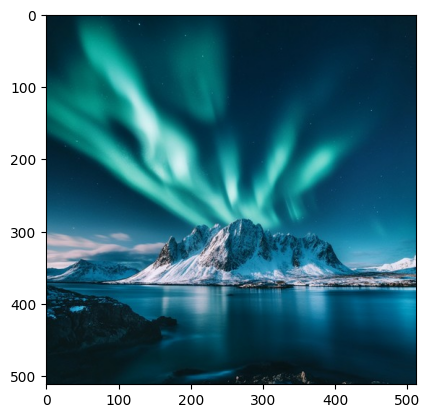

In [32]:
imshow(Style_image)

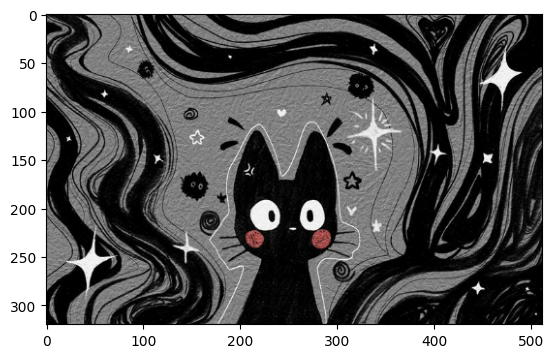

In [33]:
imshow(original_image)

# Hub Handle

In [34]:
hub_handle = 'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'

# Hub Module

In [35]:
hub_module = tf_hub.load(hub_handle)

# Neural Style Transfer

In [36]:
outputs = hub_module(Style_image,original_image)

In [37]:
outputs

[<tf.Tensor: shape=(1, 512, 512, 3), dtype=float32, numpy=
 array([[[[0.12963712, 0.11884448, 0.13098398],
          [0.13092908, 0.12120865, 0.13109513],
          [0.12956847, 0.12010019, 0.13154037],
          ...,
          [0.55066895, 0.5467975 , 0.6139281 ],
          [0.6065964 , 0.6185982 , 0.6724014 ],
          [0.6326158 , 0.6125939 , 0.6940297 ]],
 
         [[0.12861985, 0.11743004, 0.12653868],
          [0.13017568, 0.11908318, 0.12720537],
          [0.12977503, 0.11905316, 0.12860046],
          ...,
          [0.56499034, 0.55618525, 0.62080616],
          [0.61582595, 0.6240741 , 0.6715167 ],
          [0.6420912 , 0.6182195 , 0.6894613 ]],
 
         [[0.12305494, 0.10845357, 0.11301958],
          [0.12625296, 0.11191063, 0.11540159],
          [0.12924792, 0.11531933, 0.12003502],
          ...,
          [0.5590254 , 0.55380124, 0.60346323],
          [0.60629815, 0.61822796, 0.649535  ],
          [0.6337908 , 0.6181909 , 0.67678493]],
 
         ...,
 
       

# Displaying Styled Image

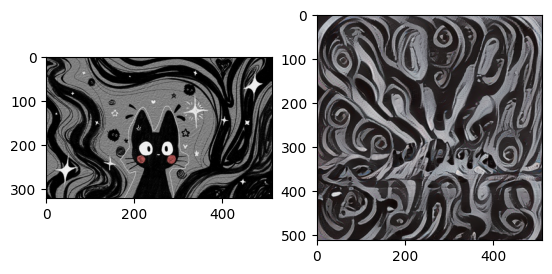

In [38]:
plt.subplot(1,2,1)
imshow(original_image)
plt.subplot(1,2,2)
imshow(outputs[0])